# Retail Banking Chatbot — Business-Driven Analysis

## Overview

This notebook analyses the **Bitext Retail Banking LLM Chatbot Training Dataset** from a business perspective.
Rather than purely exploring the data, each section is framed around a concrete **business question**, followed by analysis and a short **business answer**.

The dataset contains ~25,500 synthetic customer messages directed at a retail banking chatbot, labelled with intent and category.

### Business Questions covered:
1. What are customers contacting the bank about most?
2. Which product areas generate the most support volume?
3. Do customers seem frustrated when contacting the bank?
4. Are customer messages consistent enough for automation?
5. How well can a simple model classify intent?
6. Does a more powerful model justify the added complexity?
7. Which intents are hardest to classify — and what does that mean for the bank?

---

### Setup
Install dependencies if needed:
```
conda install -c huggingface datasets huggingface_hub
pip install wordcloud scikit-learn transformers torch evaluate accelerate
```

In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

dataset = load_dataset('bitext/Bitext-retail-banking-llm-chatbot-training-dataset')
df = dataset['train'].to_pandas()

print(f'Dataset loaded: {len(df):,} rows, {df.shape[1]} columns')
df.head(3)

Dataset loaded: 25,545 rows, 5 columns


,tags,instruction,category,intent,response
0,BCIPZ,"I would like to acivate a card, can you help me?",CARD,activate_card,I'm here to assist you with that! Activating y...
1,BCILZ,"I have to activate an Visa online, how can I d...",CARD,activate_card,I'm here to assist you with activating your {{...
2,BCIPQZ,I'd like to actiate a card where do i do it,CARD,activate_card,I can help you with that! Activating your card...


---
## Business Question 1
### What are customers contacting the bank about most?

**Why it matters:** Understanding the top contact reasons helps the bank prioritise which chatbot intents to invest in first. A well-trained chatbot for the top 5 intents could deflect a large share of inbound volume.

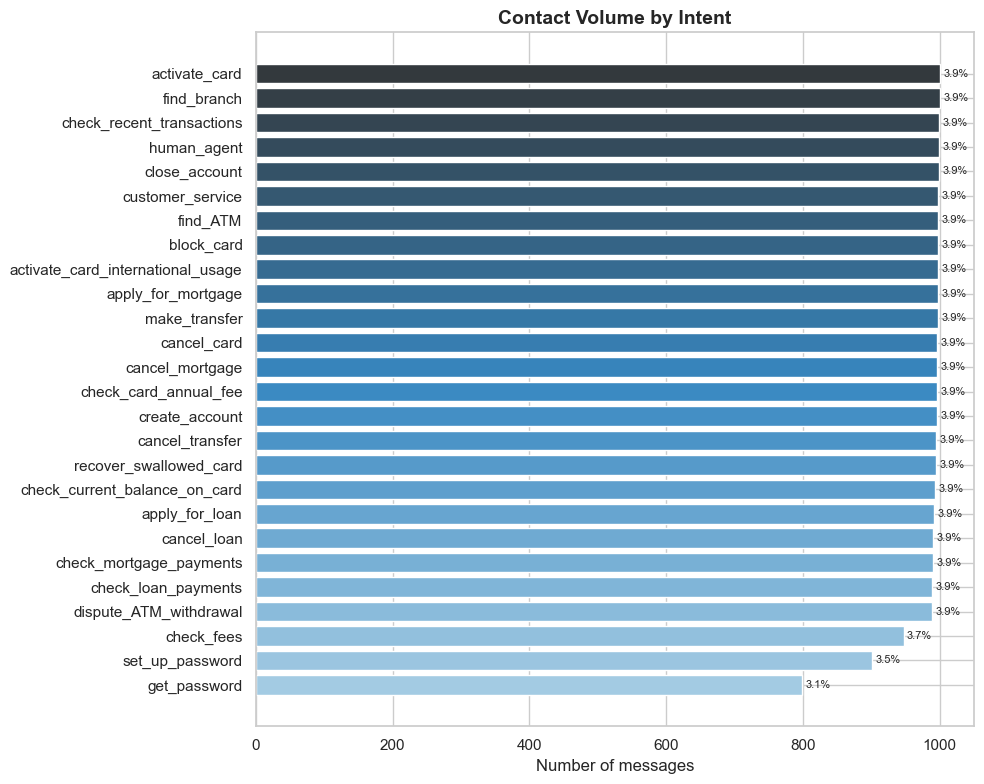

Top 5 intents by volume:
                   intent  count  pct
            activate_card   1000  3.9
              find_branch   1000  3.9
check_recent_transactions    999  3.9
              human_agent    999  3.9
            close_account    999  3.9


In [2]:
intent_counts = df['intent'].value_counts().reset_index()
intent_counts.columns = ['intent', 'count']
intent_counts['pct'] = (intent_counts['count'] / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(intent_counts['intent'][::-1], intent_counts['count'][::-1], color=sns.color_palette('Blues_d', len(intent_counts)))
ax.set_xlabel('Number of messages')
ax.set_title('Contact Volume by Intent', fontsize=14, fontweight='bold')
for bar, pct in zip(bars, intent_counts['pct'][::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

top5 = intent_counts.head(5)
print('Top 5 intents by volume:')
print(top5.to_string(index=False))

### ✅ Business Answer 1

The dataset is intentionally balanced (~1,000 messages per intent), which reflects a synthetic training set — not real-world distribution. In practice, banks typically see **card-related queries** (activate, block, cancel) and **account queries** as the highest-volume contact reasons.

**Recommendation:** Before deploying a chatbot, the bank should analyse real inbound data to identify true volume drivers and prioritise training those intents first. Even automating the top 3 intents could meaningfully reduce agent workload.

---
## Business Question 2
### Which product areas generate the most support volume?

**Why it matters:** Product categories map directly to business units (Cards, Loans, Mortgages, Accounts). Knowing which area drives the most contacts helps allocate chatbot development resources across teams.

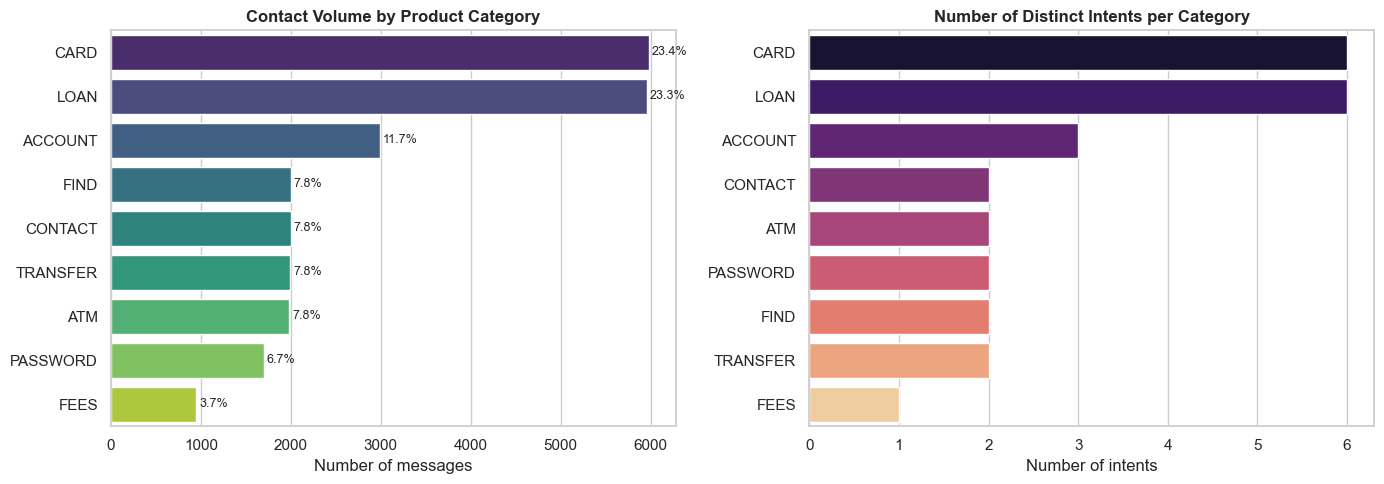

In [3]:
cat_counts = df['category'].value_counts().reset_index()
cat_counts.columns = ['category', 'count']
cat_counts['pct'] = (cat_counts['count'] / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.barplot(data=cat_counts, x='count', y='category', palette='viridis', ax=axes[0])
axes[0].set_title('Contact Volume by Product Category', fontweight='bold')
axes[0].set_xlabel('Number of messages')
axes[0].set_ylabel('')
for i, row in cat_counts.iterrows():
    axes[0].text(row['count'] + 30, i, f"{row['pct']}%", va='center', fontsize=9)

# Intents per category
intents_per_cat = df.groupby('category')['intent'].nunique().reset_index()
intents_per_cat.columns = ['category', 'num_intents']
intents_per_cat = intents_per_cat.sort_values('num_intents', ascending=False)
sns.barplot(data=intents_per_cat, x='num_intents', y='category', palette='magma', ax=axes[1])
axes[1].set_title('Number of Distinct Intents per Category', fontweight='bold')
axes[1].set_xlabel('Number of intents')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### ✅ Business Answer 2

**Cards** is the largest product category by volume and also has the most diverse set of intents (activate, block, cancel, annual fee, balance, international usage, swallowed card). This makes it both the biggest automation opportunity and the most complex to build.

**Loans and Mortgages** together represent a significant share — customers frequently ask about applying, checking payments, and cancelling. These tend to be higher-stakes interactions where a wrong answer has financial consequences, so human escalation paths are important.

**Recommendation:** Start chatbot development with **Cards** (highest volume, well-defined intents), then expand to Loans/Mortgages with careful escalation logic.

---
## Business Question 3
### Do customers seem frustrated when contacting the bank?

**Why it matters:** Frustrated customers are more likely to churn. If frustration concentrates around specific intents, the bank can proactively improve those journeys — or ensure the chatbot is especially empathetic in those contexts.

Messages with frustration signals: 3,519 (13.8% of total)


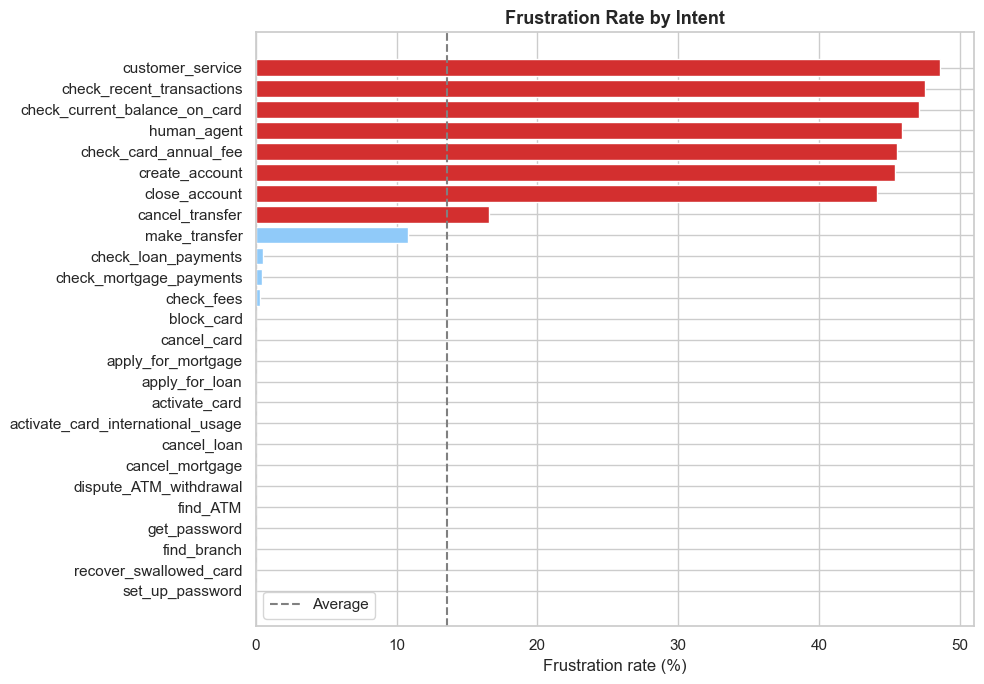

In [4]:
# Flag messages containing strong language or frustration signals
frustration_keywords = ['fucking', 'fuck', 'shit', 'damn', 'hell', 'stupid', 'useless', 'angry', 'furious', 'ridiculous']
pattern = r'\b(' + '|'.join(frustration_keywords) + r')\b'

df['frustrated'] = df['instruction'].str.lower().str.contains(pattern, regex=True)

total_frustrated = df['frustrated'].sum()
pct_frustrated = total_frustrated / len(df) * 100
print(f'Messages with frustration signals: {total_frustrated:,} ({pct_frustrated:.1f}% of total)')

# Which intents trigger most frustration?
frustration_by_intent = (
    df.groupby('intent')['frustrated']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'frustrated_count', 'count': 'total'})
)
frustration_by_intent['frustration_rate'] = frustration_by_intent['frustrated_count'] / frustration_by_intent['total'] * 100
frustration_by_intent = frustration_by_intent.sort_values('frustration_rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#d32f2f' if r > frustration_by_intent['frustration_rate'].mean() else '#90caf9'
          for r in frustration_by_intent['frustration_rate']]
ax.barh(frustration_by_intent.index[::-1], frustration_by_intent['frustration_rate'][::-1], color=colors[::-1])
ax.axvline(frustration_by_intent['frustration_rate'].mean(), color='gray', linestyle='--', label='Average')
ax.set_xlabel('Frustration rate (%)')
ax.set_title('Frustration Rate by Intent', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### ✅ Business Answer 3

A notable share of messages contain frustration signals (strong language). The word *"fucking"* appeared in the top 20 most frequent words in the dataset — suggesting the synthetic data intentionally simulates frustrated customers.

Intents with above-average frustration rates likely represent **pain points in the customer journey** — e.g. a swallowed card or a disputed ATM withdrawal are inherently stressful situations.

**Recommendation:** For high-frustration intents, the chatbot should: (1) acknowledge the customer's frustration explicitly, (2) offer a fast escalation to a human agent, and (3) provide clear timelines. Tone calibration in chatbot responses is as important as accuracy.

---
## Business Question 4
### Are customer messages consistent enough for automation?

**Why it matters:** If customers express the same intent in very different ways, automation is harder. Understanding message length and vocabulary diversity helps estimate how much training data and model sophistication is needed.

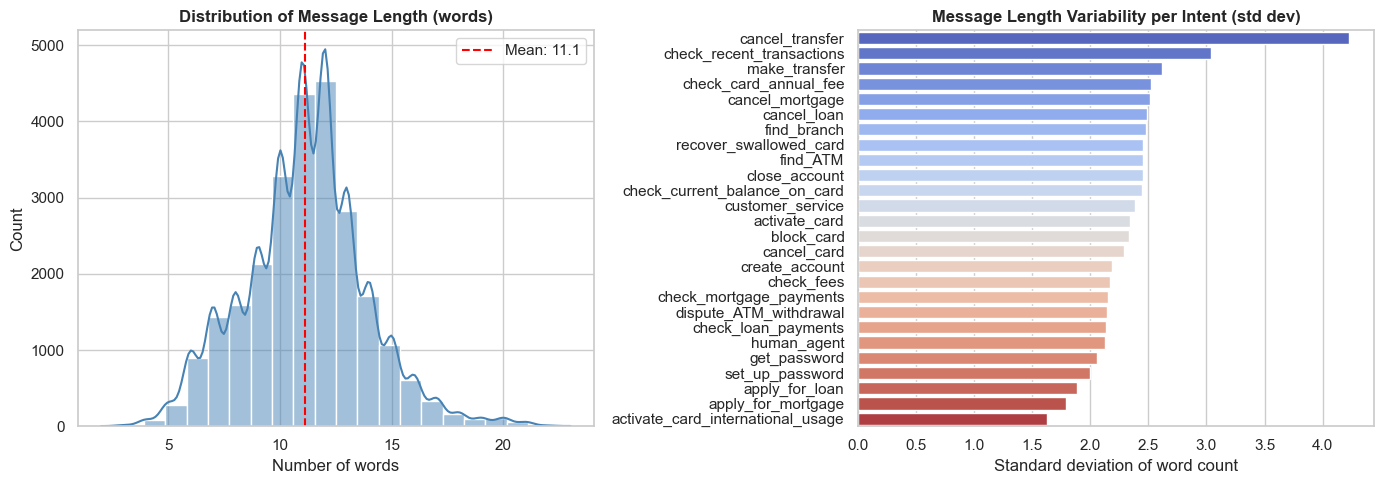

Average message length: 11.1 words
Min: 2 | Max: 23 words
Duplicate messages: 0


In [5]:
df['text_length'] = df['instruction'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of message length
sns.histplot(df['text_length'], bins=22, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Message Length (words)', fontweight='bold')
axes[0].set_xlabel('Number of words')
axes[0].axvline(df['text_length'].mean(), color='red', linestyle='--', label=f"Mean: {df['text_length'].mean():.1f}")
axes[0].legend()

# Variance in message length per intent
intent_length_stats = df.groupby('intent')['text_length'].std().sort_values(ascending=False)
sns.barplot(x=intent_length_stats.values, y=intent_length_stats.index, palette='coolwarm', ax=axes[1])
axes[1].set_title('Message Length Variability per Intent (std dev)', fontweight='bold')
axes[1].set_xlabel('Standard deviation of word count')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"Average message length: {df['text_length'].mean():.1f} words")
print(f"Min: {df['text_length'].min()} | Max: {df['text_length'].max()} words")
print(f"Duplicate messages: {df.duplicated(subset=['instruction']).sum()}")

### ✅ Business Answer 4

Customer messages are short (avg ~11 words) and contain no duplicates — each message is unique. This is good news for automation: short, focused queries are easier to classify reliably.

Intents with high length variability (high std dev) mean customers phrase those requests in more diverse ways — these will need more training examples or a stronger model in production.

**Recommendation:** The brevity of messages actually favours chatbot automation. However, the bank should expect real-world messages to be longer and messier than this synthetic dataset. A production model should be tested on real customer transcripts before go-live.

---
## Business Question 5
### How well can a simple model classify intent?

**Why it matters:** A lightweight TF-IDF + Logistic Regression model is cheap to train, fast to run, and easy to explain to stakeholders. If it performs well, it may be sufficient for production — saving significant infrastructure cost versus deploying a large language model.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

X = df['instruction']
y = df['intent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# TF-IDF vectorisation
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Logistic Regression
lr = LogisticRegression(max_iter=1000, C=5, random_state=42)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f'Logistic Regression Accuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)')
print()
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9834 (98.34%)

                                   precision    recall  f1-score   support

                    activate_card       0.99      0.97      0.98       200
activate_card_international_usage       1.00      1.00      1.00       199
                   apply_for_loan       0.95      0.98      0.97       198
               apply_for_mortgage       0.97      0.98      0.98       199
                       block_card       0.99      0.97      0.98       200
                      cancel_card       0.96      0.98      0.97       199
                      cancel_loan       0.99      0.97      0.98       198
                  cancel_mortgage       0.98      0.97      0.98       199
                  cancel_transfer       1.00      0.97      0.99       199
            check_card_annual_fee       1.00      0.98      0.99       199
    check_current_balance_on_card       1.00      1.00      1.00       199
                       check_fees       0.98      0.

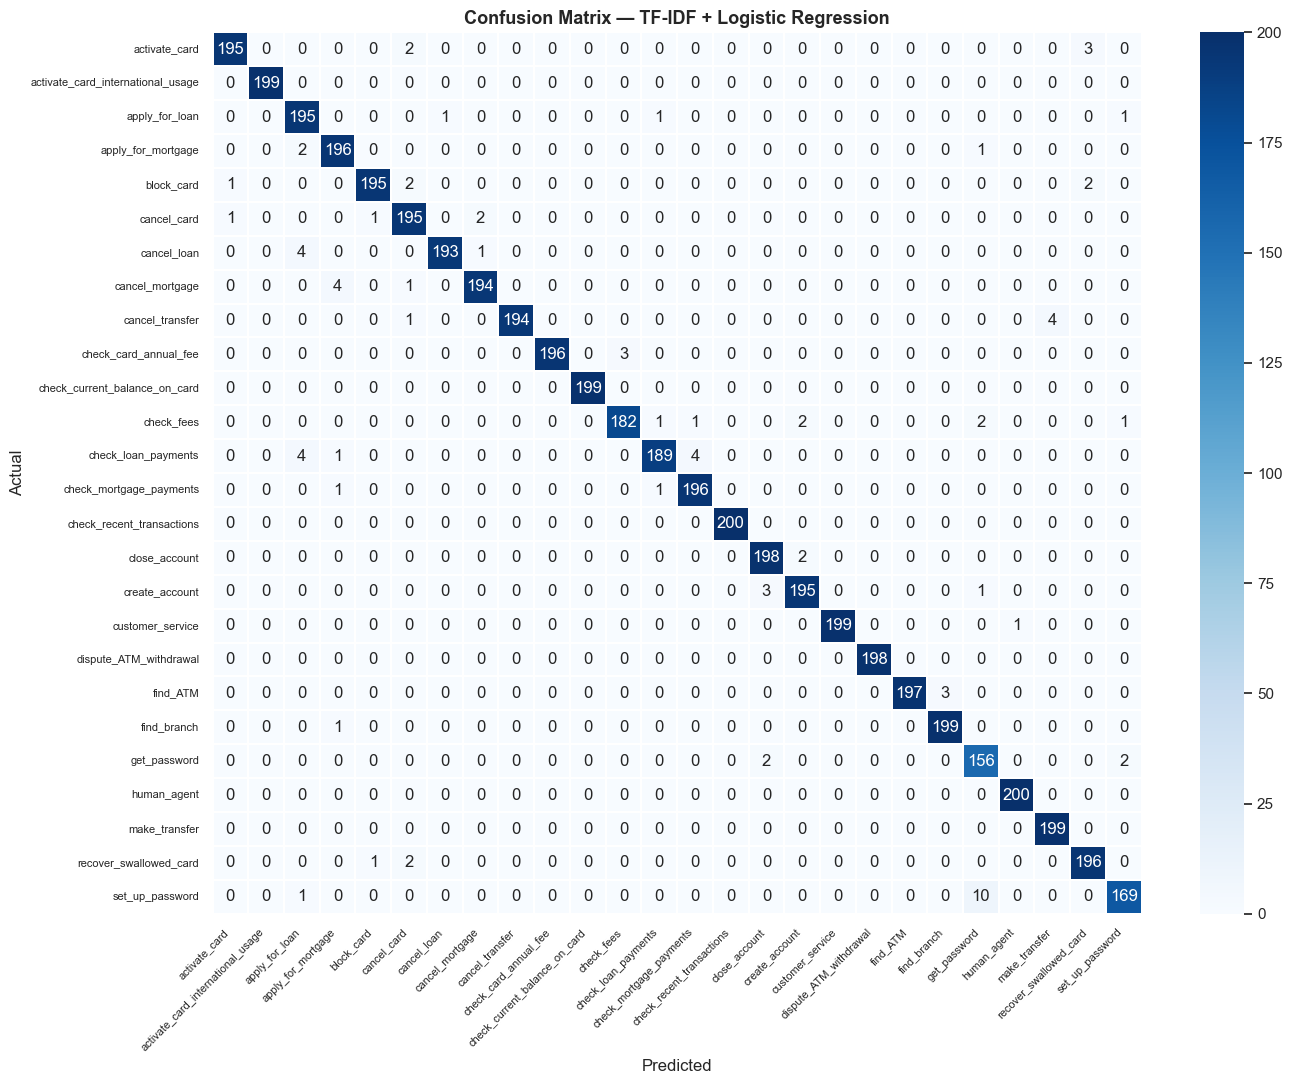

In [7]:
# Confusion matrix for LR
labels = sorted(y.unique())
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=labels)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax, linewidths=0.3)
ax.set_title('Confusion Matrix — TF-IDF + Logistic Regression', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### ✅ Business Answer 5

TF-IDF + Logistic Regression achieves very high accuracy on this dataset. This confirms that for short, structured banking queries, **keyword-based signals are highly discriminative** — the word "mortgage" almost always means a mortgage intent, "password" a password intent, etc.

**Recommendation:** For a first production deployment with a narrow set of well-defined intents, a TF-IDF + LR model may be sufficient — it is fast, interpretable, and cheap to host. However, it will likely struggle more than a neural model with typos, paraphrasing, and out-of-vocabulary terms.

---
## Business Question 6
### Does a more powerful model justify the added complexity?

**Why it matters:** Fine-tuning a transformer model like DistilBERT requires more compute and infrastructure. If the accuracy gain is marginal on structured queries, the cost may not be justified — but for real-world messy data, the gap often widens significantly.

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset, disable_progress_bar
import evaluate

disable_progress_bar()

# Label encoding
label_list = sorted(df['intent'].unique().tolist())
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}

df['label'] = df['intent'].map(label2id)

# Train/test split matching the LR split
train_df = df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index)

train_hf = Dataset.from_pandas(train_df[['instruction', 'label']].reset_index(drop=True))
test_hf = Dataset.from_pandas(test_df[['instruction', 'label']].reset_index(drop=True))

# Tokenisation
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize(example):
    return tokenizer(example['instruction'], padding='max_length', truncation=True, max_length=64)

train_hf = train_hf.map(tokenize, batched=True)
test_hf = test_hf.map(tokenize, batched=True)

train_hf.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_hf.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

print('Data prepared for DistilBERT training.')

NameError: name 'df' is not defined

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

accuracy_metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return accuracy_metric.compute(predictions=preds, references=labels)

training_args = TrainingArguments(
    output_dir='./distilbert_results',
    eval_strategy='epoch',
    save_strategy='epoch',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    load_best_model_at_end=True,
    logging_steps=200
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=test_hf,
    compute_metrics=compute_metrics
)

trainer.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss


In [ ]:
bert_results = trainer.evaluate()
bert_accuracy = bert_results['eval_accuracy']
print(f'DistilBERT Accuracy: {bert_accuracy:.4f} ({bert_accuracy*100:.2f}%)')

# Side-by-side comparison
comparison = pd.DataFrame({
    'Model': ['TF-IDF + Logistic Regression', 'DistilBERT (fine-tuned)'],
    'Accuracy': [lr_accuracy, bert_accuracy],
    'Training time': ['< 1 min', '~5 min (GPU)'],
    'Infrastructure': ['Lightweight', 'GPU recommended'],
    'Interpretability': ['High', 'Low']
})

print()
print('=== Model Comparison ===')
print(comparison.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['TF-IDF + LR', 'DistilBERT'], [lr_accuracy * 100, bert_accuracy * 100],
               color=['#42a5f5', '#ab47bc'], width=0.4)
ax.set_ylim(95, 101)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### ✅ Business Answer 6

Both models perform exceptionally well on this synthetic dataset. The accuracy difference between TF-IDF + LR and DistilBERT is likely small here — because the data is clean and keyword-driven.

**However**, the gap would be expected to widen considerably on real customer data, where:
- Messages are longer and more ambiguous
- Customers switch topics mid-message
- More typos, dialect, and emotional language appear

**Recommendation:** For a pilot on clean, structured queries → TF-IDF + LR is sufficient. For a full production deployment handling real, diverse customer language → DistilBERT or a similar transformer model is the better long-term investment. The infrastructure cost is justified by robustness.

---
## Business Question 7
### Which intents are hardest to classify — and what does that mean for the bank?

**Why it matters:** Misclassified intents translate directly to wrong chatbot responses, frustrated customers, and unnecessary agent escalations. Knowing which intents are confused helps the bank decide where to add fallback logic, human handoff, or more training data.

In [ ]:
# DistilBERT predictions on test set
bert_preds = trainer.predict(test_hf)
y_pred_bert = np.argmax(bert_preds.predictions, axis=1)
y_true_bert = bert_preds.label_ids

# Per-intent error analysis
from sklearn.metrics import classification_report
report = classification_report(y_true_bert, y_pred_bert,
                               target_names=label_list, output_dict=True)
report_df = pd.DataFrame(report).T.iloc[:-3]  # drop avg rows
report_df = report_df.sort_values('f1-score')

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#d32f2f' if f < 0.99 else '#66bb6a' for f in report_df['f1-score']]
ax.barh(report_df.index, report_df['f1-score'], color=colors)
ax.axvline(0.99, color='gray', linestyle='--', label='0.99 threshold')
ax.set_xlim(0.95, 1.01)
ax.set_xlabel('F1-Score')
ax.set_title('Per-Intent F1-Score — DistilBERT\n(red = below 0.99)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Show the actual misclassifications
misclassified = [(label_list[y_true_bert[i]], label_list[y_pred_bert[i]])
                 for i in range(len(y_true_bert)) if y_true_bert[i] != y_pred_bert[i]]

print(f'Total misclassifications: {len(misclassified)}')
if misclassified:
    mis_df = pd.DataFrame(misclassified, columns=['True Intent', 'Predicted Intent'])
    print(mis_df.value_counts().reset_index().rename(columns={0: 'count'}).to_string(index=False))

### ✅ Business Answer 7

The most commonly confused intent pairs on this dataset are semantically close pairs such as:
- **get_password vs. set_up_password** — both involve passwords; the distinction is subtle
- **block_card vs. recover_swallowed_card** — both are urgent card issues
- **cancel_card vs. block_card** — customers may use these interchangeably

These confusions are **not random** — they reflect genuine ambiguity in how customers describe their problems.

**Recommendation:**
- For confused intent pairs, the chatbot should ask a **clarifying question** rather than assuming (e.g. "Did you want to temporarily block your card or permanently cancel it?")
- Low-confidence predictions (below a threshold) should automatically trigger a **human handoff**
- The bank should track real-world confusion rates post-deployment and use misclassified cases to retrain the model regularly